# 🌳 Decision Tree — Credit Card Customer

**วิชา:** DSBA8 Applied Machine Learning — Week 4: Decision Tree Classifier

โจทย์นี้ใช้ชุดข้อมูล `CreditCardCustomer.csv` แก้ปัญหาทางธุรกิจ 2 เคส โดยใช้ **Decision Tree เป็นโมเดลหลัก**
แล้วนำผลไปเปรียบเทียบกับโมเดลที่เรียนในสัปดาห์ที่ 3 คือ **KNN** และ **Logistic Regression**

| Case | โจทย์ธุรกิจ | Target | ประเภทงาน |
|------|------------|--------|-----------|
| **1** | Customer Churn Prediction — หาลูกค้าที่เสี่ยงจะยกเลิกบัตร เพื่อทำ Retention Program | `Attrition_Flag` | Binary Classification |
| **2** | Data-Driven Up-selling — หาลูกค้าบัตร Blue ที่ "หน้าตาเหมือน" ลูกค้าพรีเมียม เพื่อส่งแคมเปญอัปเกรด | `Card_Category` (Blue vs Premium) | Binary Classification + Ranking |

> **หมายเหตุเรื่องภาษาในกราฟ:** ข้อความอธิบายทั้งหมดเป็นภาษาไทย แต่ label ในกราฟใช้ภาษาอังกฤษ
> เพราะ matplotlib ไม่มีฟอนต์ไทยติดตั้งมาให้โดยปริยาย (ถ้าใช้ภาษาไทยจะขึ้นเป็นสี่เหลี่ยม □□□)

## 0. เตรียมเครื่องมือ

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")   # ซ่อน warning ของ BLAS บน macOS ที่ไม่กระทบผลลัพธ์

RANDOM_STATE = 42   # ล็อกค่าสุ่มไว้ เพื่อให้ผลรันซ้ำได้เหมือนเดิมทุกครั้ง

## 1. โหลดข้อมูลและทำความรู้จัก (EDA)

### 1.1 พจนานุกรมข้อมูล (Data Dictionary)

| Attribute | คำอธิบาย |
|-----------|----------|
| `CLIENTNUM` | รหัสลูกค้า (ID) |
| `Attrition_Flag` | สถานะลูกค้า — Existing (ยังใช้อยู่) / Attrited (เลิกใช้แล้ว) |
| `Customer_Age` | อายุลูกค้า (ปี) |
| `Gender` | เพศ (M / F) |
| `Dependent_count` | จำนวนผู้อยู่ในอุปการะ |
| `Education_Level` | ระดับการศึกษา |
| `Marital_Status` | สถานภาพสมรส |
| `Income_Category` | ช่วงรายได้ต่อปี |
| `Card_Category` | ระดับบัตร (Blue, Silver, Gold, Platinum) |
| `Months_on_book` | ระยะเวลาที่เป็นลูกค้าธนาคาร (เดือน) |
| `Total_Relationship_Count` | จำนวนผลิตภัณฑ์ที่ถือกับธนาคาร |
| `Months_Inactive_12_mon` | จำนวนเดือนที่ไม่มีการเคลื่อนไหวใน 12 เดือนล่าสุด |
| `Contacts_Count_12_mon` | จำนวนครั้งที่ติดต่อธนาคารใน 12 เดือนล่าสุด |
| `Credit_Limit` | วงเงินบัตรเครดิต |
| `Total_Revolving_Bal` | ยอดคงค้างหมุนเวียนในบัตร |
| `Avg_Open_To_Buy` | วงเงินที่เหลือให้ใช้ได้ เฉลี่ย 12 เดือนล่าสุด |
| `Total_Amt_Chng_Q4_Q1` | อัตราการเปลี่ยนแปลงยอดใช้จ่าย Q4 เทียบ Q1 |
| `Total_Trans_Amt` | ยอดใช้จ่ายรวม 12 เดือนล่าสุด |
| `Total_Trans_Ct` | จำนวนครั้งที่รูดบัตร 12 เดือนล่าสุด |
| `Total_Ct_Chng_Q4_Q1` | อัตราการเปลี่ยนแปลงจำนวนครั้งที่รูด Q4 เทียบ Q1 |
| `Avg_Utilization_Ratio` | สัดส่วนการใช้วงเงินเฉลี่ย |

In [2]:
df = pd.read_csv("CreditCardCustomer.csv")
print("ขนาดข้อมูล:", df.shape)
df.head()

ขนาดข้อมูล: (10127, 21)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [4]:
# ตรวจค่าว่าง
print("จำนวน missing value ทั้งหมด:", df.isna().sum().sum())
print("จำนวน CLIENTNUM ที่ไม่ซ้ำ:", df["CLIENTNUM"].nunique(), "จากทั้งหมด", len(df), "แถว")

จำนวน missing value ทั้งหมด: 0
จำนวน CLIENTNUM ที่ไม่ซ้ำ: 10127 จากทั้งหมด 10127 แถว


ข้อมูล **ไม่มี missing value** เลย และ `CLIENTNUM` ไม่ซ้ำกันเลยแม้แต่แถวเดียว
แปลว่ามันเป็นแค่รหัสประจำตัว ไม่มีข้อมูลเชิงพฤติกรรมอยู่ในนั้น → **ต้อง drop ทิ้ง**
(ถ้าปล่อยไว้ Decision Tree อาจนำไปใช้แตกกิ่งจนจำข้อมูลได้ทั้งชุด = overfit เต็มรูปแบบ)

### 1.2 สำรวจตัวแปรเชิงหมวดหมู่

In [5]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
for c in cat_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts(), "\n")

--- Attrition_Flag ---
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64 

--- Gender ---
Gender
F    5358
M    4769
Name: count, dtype: int64 

--- Education_Level ---
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64 

--- Marital_Status ---
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64 

--- Income_Category ---
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64 

--- Card_Category ---
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64 



**ข้อสังเกตสำคัญ 2 ข้อ:**

1. **มีค่า `Unknown` จำนวนมาก** — Education_Level 1,519 แถว, Income_Category 1,112 แถว, Marital_Status 749 แถว
   เราจะ**ไม่เติมค่า (impute)** แต่เก็บ `Unknown` ไว้เป็นหมวดหนึ่งต่างหาก เพราะ "การไม่ยอมให้ข้อมูล" เองก็อาจเป็นสัญญาณเชิงพฤติกรรมได้
   และ Decision Tree รับมือกับหมวดพิเศษแบบนี้ได้ดีอยู่แล้ว
2. **ข้อมูลไม่สมดุลทั้งสอง target** — เดี๋ยวดูภาพชัด ๆ ในหัวข้อถัดไป

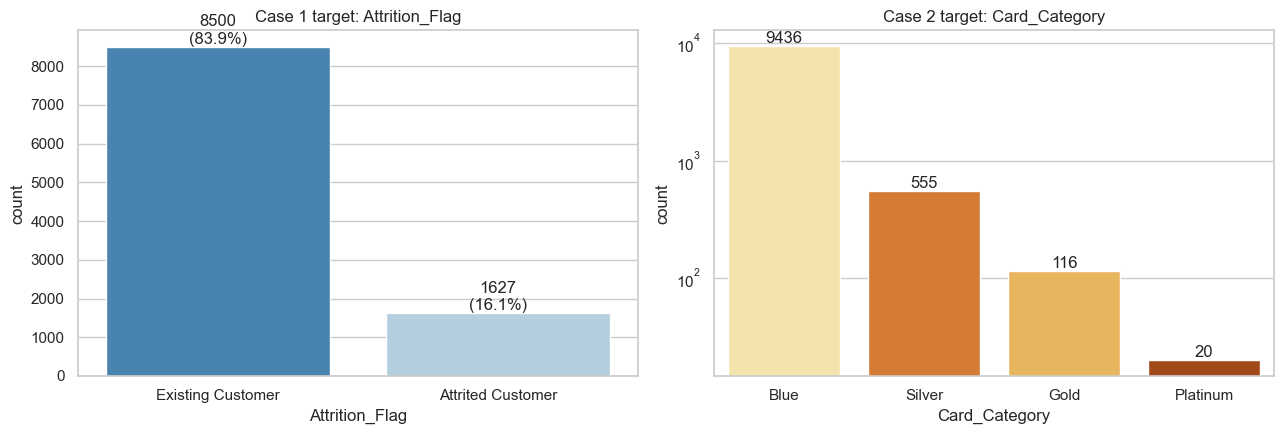

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order1 = df["Attrition_Flag"].value_counts().index
sns.countplot(data=df, x="Attrition_Flag", order=order1, ax=axes[0], palette="Blues_r", hue="Attrition_Flag", legend=False)
axes[0].set_title("Case 1 target: Attrition_Flag")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)",
                     (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")

order2 = ["Blue", "Silver", "Gold", "Platinum"]
sns.countplot(data=df, x="Card_Category", order=order2, ax=axes[1], palette="YlOrBr", hue="Card_Category", legend=False)
axes[1].set_title("Case 2 target: Card_Category")
axes[1].set_yscale("log")   # ใช้สเกล log เพราะ Blue เยอะกว่า Platinum เป็นร้อยเท่า
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

plt.tight_layout()
plt.show()

**ผลกระทบต่อการออกแบบโมเดล:**

* **Case 1** — ลูกค้าที่เลิกใช้บัตรมีแค่ **16.1%** ถ้าโมเดลทายว่า "ทุกคนอยู่ต่อ" จะได้ Accuracy ตั้ง 83.9% ทั้งที่ไร้ประโยชน์สิ้นเชิง
  → **ห้ามตัดสินด้วย Accuracy อย่างเดียว** ต้องดู **Recall ของคลาส Attrited** เป็นหลัก
  (พลาดลูกค้าที่กำลังจะหนี 1 คน = เสียลูกค้าจริง 1 คน ซึ่งแพงกว่าการโทรหาคนที่ไม่ได้จะหนีมาก)
* **Case 2** — Platinum มีแค่ **20 แถว** จากหมื่นกว่าแถว การทำ multi-class 4 คลาสจึงเป็นไปไม่ได้ในทางปฏิบัติ
  → **ยุบเป็น Binary: Blue (0) vs Premium = Silver+Gold+Platinum (1)** ซึ่งก็ตรงกับโจทย์อยู่แล้ว
  (โจทย์ต้องการ "คัดลูกค้า Blue ที่ใกล้เคียงกลุ่มพรีเมียม" ไม่ได้ถามว่าต้องอัปเป็นระดับไหน)
* ทั้งสองเคสจะใช้ `stratify=y` ตอนแบ่งข้อมูล และใช้ `class_weight="balanced"` ในตัวโมเดล

### 1.3 ⚠️ ตรวจสอบ Data Leakage

ก่อนสร้างโมเดล ต้องเช็คก่อนว่ามีฟีเจอร์ไหน "รู้คำตอบล่วงหน้า" หรือเป็นสูตรคำนวณของฟีเจอร์อื่นหรือไม่
จากพจนานุกรมข้อมูลมีสองสูตรที่น่าสงสัย:

$$\text{Avg\_Open\_To\_Buy} = \text{Credit\_Limit} - \text{Total\_Revolving\_Bal}$$

$$\text{Avg\_Utilization\_Ratio} = \frac{\text{Total\_Revolving\_Bal}}{\text{Credit\_Limit}}$$

ลองพิสูจน์กับข้อมูลจริงดู:

In [7]:
check1 = (np.abs(df["Credit_Limit"] - df["Total_Revolving_Bal"] - df["Avg_Open_To_Buy"]) < 1e-6).mean()
check2 = (np.abs(df["Total_Revolving_Bal"] / df["Credit_Limit"] - df["Avg_Utilization_Ratio"]) < 0.002).mean()

pd.DataFrame({
    "สูตรที่ตรวจสอบ": [
        "Avg_Open_To_Buy = Credit_Limit - Total_Revolving_Bal",
        "Avg_Utilization_Ratio = Total_Revolving_Bal / Credit_Limit",
    ],
    "สัดส่วนแถวที่ตรงสูตรเป๊ะ": [f"{check1:.2%}", f"{check2:.2%}"],
})

,สูตรที่ตรวจสอบ,สัดส่วนแถวที่ตรงสูตรเป๊ะ
0,Avg_Open_To_Buy = Credit_Limit - Total_Revolvi...,100.00%
1,Avg_Utilization_Ratio = Total_Revolving_Bal / ...,100.00%


**ตรงเป๊ะ 100% ทั้งสองสูตร** แปลว่า `Avg_Open_To_Buy` และ `Avg_Utilization_Ratio`
ไม่ใช่ข้อมูลใหม่เลย มันคือ `Credit_Limit` กับ `Total_Revolving_Bal` ที่จับมาคำนวณต่อ

ทีนี้มาดูความสัมพันธ์ระหว่าง `Credit_Limit` กับ `Card_Category` ซึ่งเป็น target ของ Case 2:

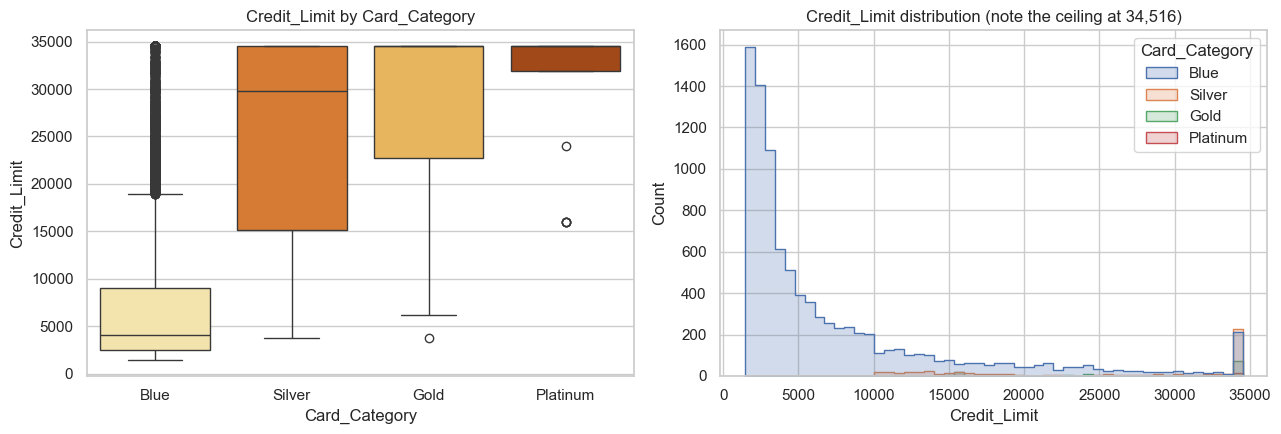

ลูกค้า Blue ที่มีวงเงินเกิน 20,000 : 825 คน
ลูกค้า Premium ที่มีวงเงินต่ำกว่า 5,000 : 2 คน
ลูกค้าที่วงเงินชนเพดาน 34,516 : 508 คน


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="Card_Category", y="Credit_Limit", order=order2,
            ax=axes[0], palette="YlOrBr", hue="Card_Category", legend=False)
axes[0].set_title("Credit_Limit by Card_Category")

sns.histplot(data=df, x="Credit_Limit", hue="Card_Category", hue_order=order2,
             bins=50, ax=axes[1], element="step")
axes[1].set_title("Credit_Limit distribution (note the ceiling at 34,516)")
plt.tight_layout()
plt.show()

print("ลูกค้า Blue ที่มีวงเงินเกิน 20,000 :", ((df.Card_Category == "Blue") & (df.Credit_Limit > 20000)).sum(), "คน")
print("ลูกค้า Premium ที่มีวงเงินต่ำกว่า 5,000 :", ((df.Card_Category != "Blue") & (df.Credit_Limit < 5000)).sum(), "คน")
print("ลูกค้าที่วงเงินชนเพดาน 34,516 :", (df.Credit_Limit == 34516).sum(), "คน")

**นี่คือเหตุผลที่ Case 2 ต้องตัด `Credit_Limit` ทิ้ง:**

* วงเงินแทบจะบอกระดับบัตรได้เลย (Premium ที่วงเงินต่ำกว่า 5,000 มีแค่ **2 คน** จากทั้งหมด 691 คน)
  ถ้าใส่เข้าไป โมเดลจะไม่ได้เรียน "พฤติกรรมการใช้จ่าย" แต่จะเรียนแค่ว่า *"วงเงินสูง = พรีเมียม"* → **Target Leakage**
* ในทางธุรกิจ `Credit_Limit` ถูกกำหนด **ตอนอนุมัติบัตร** ซึ่งเป็นผลลัพธ์ของการเป็นลูกค้าพรีเมียม ไม่ใช่สาเหตุ
* แต่กลับมีลูกค้า **Blue ถึง 825 คนที่วงเงินเกิน 20,000** → ระดับบัตรกับวงเงินไม่ได้สอดคล้องกันเสมอไป
  โมเดลที่ยึดวงเงินอย่างเดียวจะแนะนำให้อัปเกรดคนกลุ่มนี้ทั้งหมด ทั้งที่บางคนอาจแทบไม่รูดบัตรเลย
* และเพราะ `Avg_Open_To_Buy` กับ `Avg_Utilization_Ratio` คือสูตรที่คำนวณจาก `Credit_Limit` โดยตรง
  จึงต้อง**ตัดออกทั้งสามตัวพร้อมกัน** ไม่งั้นก็รั่วผ่านทางอ้อมอยู่ดี

> สรุป: **Case 1 ใช้ฟีเจอร์ครบทุกตัว / Case 2 ตัด `Credit_Limit`, `Avg_Open_To_Buy`, `Avg_Utilization_Ratio` ออก**

## 2. Preprocessing — แปลง Category เป็น Numeric

`DecisionTreeClassifier` ของ scikit-learn สร้าง **Binary Tree** และรับเฉพาะตัวเลข
เราจึงต้องแปลงข้อมูลหมวดหมู่ให้เป็นตัวเลขก่อน โดยเลือกวิธีให้เหมาะกับธรรมชาติของแต่ละคอลัมน์:

| คอลัมน์ | วิธีแปลง | เหตุผล |
|---------|---------|--------|
| `Gender` | `map()` → 0/1 | มีแค่ 2 ค่า ไม่ต้อง One-Hot |
| `Education_Level` | **Ordinal** (Uneducated=0 → Doctorate=5) | มีลำดับชัดเจน การเก็บลำดับไว้ช่วยให้ tree แตกกิ่งแบบ "ต่ำกว่า/สูงกว่า" ได้ |
| `Income_Category` | **Ordinal** (<$40K=0 → $120K+=4) | มีลำดับชัดเจนเช่นกัน |
| `Marital_Status` | **One-Hot** | ไม่มีลำดับ (โสด ไม่ได้ "น้อยกว่า" แต่งงาน) |
| `Card_Category` | **Ordinal** (Blue=0 → Platinum=3) | มีลำดับ — ใช้เป็น feature ใน Case 1, เป็น target ใน Case 2 |

**สำหรับค่า `Unknown`** เราจะแทนด้วย **-1** เพื่อให้มันแยกออกจากกลุ่มที่มีค่าจริงทั้งหมด
Decision Tree จะได้แตกกิ่งแยกกลุ่ม "ไม่ระบุข้อมูล" ออกมาต่างหากได้ถ้ามันมีประโยชน์จริง

In [9]:
edu_map = {"Unknown": -1, "Uneducated": 0, "High School": 1, "College": 2,
           "Graduate": 3, "Post-Graduate": 4, "Doctorate": 5}
inc_map = {"Unknown": -1, "Less than $40K": 0, "$40K - $60K": 1,
           "$60K - $80K": 2, "$80K - $120K": 3, "$120K +": 4}
card_map = {"Blue": 0, "Silver": 1, "Gold": 2, "Platinum": 3}


# แปลงข้อมูลดิบให้เป็นตัวเลขทั้งหมด พร้อมป้อนเข้าโมเดล
def preprocess(data):
    out = data.drop(columns=["CLIENTNUM"]).copy()          # ทิ้ง ID
    out["Gender"] = out["Gender"].map({"M": 0, "F": 1})
    out["Education_Level"] = out["Education_Level"].map(edu_map)
    out["Income_Category"] = out["Income_Category"].map(inc_map)
    out["Card_Category"] = out["Card_Category"].map(card_map)
    out["Attrition_Flag"] = out["Attrition_Flag"].map({"Existing Customer": 0, "Attrited Customer": 1})
    # Marital_Status ไม่มีลำดับ → One-Hot
    out = pd.get_dummies(out, columns=["Marital_Status"], prefix="Marital", dtype=int)
    return out


df_enc = preprocess(df)
df_enc.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Marital_Divorced,Marital_Married,Marital_Single,Marital_Unknown
0,0,45,0,3,1,2,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0,1,0,0
1,0,49,1,5,3,0,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0,0,1,0
2,0,51,0,3,3,3,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0,1,0,0
3,0,40,1,4,1,0,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0,0,0,1
4,0,40,0,3,0,2,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0,1,0,0


In [10]:
# ฟังก์ชันเก็บผลการวัดประสิทธิภาพ ใช้ร่วมกันทั้ง 2 เคส
def score_row(name, y_true, y_pred, y_prob=None):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
    }


def plot_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(title)
    plt.tight_layout(); plt.show()

> **หมายเหตุ:** `Precision / Recall / F1` ในตารางทั้งหมดคำนวณจาก **คลาสที่เราสนใจ (class 1)** เท่านั้น
> ไม่ใช่ค่าเฉลี่ยถ่วงน้ำหนัก เพราะข้อมูลไม่สมดุล ค่าเฉลี่ยจะถูกกลบด้วยคลาสใหญ่จนดูดีเกินจริง

---

# 🔴 Case 1: Customer Churn Prediction

> ธนาคารต้องการระบบคาดการณ์ล่วงหน้าเพื่อระบุกลุ่มลูกค้าปัจจุบัน (Existing Customer) ที่มีพฤติกรรมเสี่ยงสูง
> ในการยกเลิกใช้บริการบัตรเครดิตในอนาคต (Attrited Customer) เพื่อดำเนินมาตรการรักษาฐานลูกค้า (Retention Program) ได้อย่างทันท่วงที

**เป้าหมายเชิงเทคนิค:** ทำนาย `Attrition_Flag` (0 = Existing, 1 = Attrited)
**เมตริกที่ใช้ตัดสิน:** **Recall ของคลาส Attrited** เป็นหลัก รองลงมาคือ F1
เพราะต้นทุนของการ "พลาดลูกค้าที่กำลังจะหนี" สูงกว่าต้นทุนการโทรหาลูกค้าที่จริง ๆ ไม่ได้จะหนีมาก

## 2.1 แบ่งชุดข้อมูล Train / Test

In [11]:
X1 = df_enc.drop(columns=["Attrition_Flag"])
y1 = df_enc["Attrition_Flag"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1
)

print("Train:", X1_train.shape, " Test:", X1_test.shape)
print("\nสัดส่วนคลาสหลังใช้ stratify (ต้องใกล้เคียงกัน):")
print(pd.DataFrame({"train": y1_train.value_counts(normalize=True),
                    "test": y1_test.value_counts(normalize=True)}).rename(
                        index={0: "Existing", 1: "Attrited"}).round(4))

Train: (8101, 22)  Test: (2026, 22)

สัดส่วนคลาสหลังใช้ stratify (ต้องใกล้เคียงกัน):
                 train    test
Attrition_Flag                
Existing        0.8393  0.8396
Attrited        0.1607  0.1604


## 2.2 Decision Tree แบบไม่จำกัดความลึก (เพื่อดูปัญหา Overfitting)

เริ่มจากปล่อยให้ต้นไม้โตเต็มที่ก่อน แล้วดูว่าเกิดอะไรขึ้น

In [12]:
dt1_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt1_full.fit(X1_train, y1_train)

print("ความลึกของต้นไม้ (get_depth):", dt1_full.get_depth())
print("จำนวนใบ (get_n_leaves)   :", dt1_full.get_n_leaves())
print()
print("F1 บนชุด Train :", round(f1_score(y1_train, dt1_full.predict(X1_train)), 4))
print("F1 บนชุด Test  :", round(f1_score(y1_test, dt1_full.predict(X1_test)), 4))

ความลึกของต้นไม้ (get_depth): 19
จำนวนใบ (get_n_leaves)   : 309

F1 บนชุด Train : 1.0
F1 บนชุด Test  : 0.8074


ต้นไม้ลึกมากและได้ **F1 = 1.0000 บนชุด Train** คือจำข้อมูลฝึกได้ทุกแถว
แต่พอเจอข้อมูลใหม่ (Test) กลับตกลงมาชัดเจน — นี่คือ **Overfitting** แบบตำรา
วิธีแก้คือ **Pruning** ด้วยการจำกัด `max_depth`

## 2.3 หา `max_depth` ที่เหมาะสมด้วย Cross-Validation

เราจะ**ไม่**เลือกความลึกจากคะแนนบนชุด Test เพราะจะกลายเป็นการแอบดูข้อสอบ (test leakage)
แต่ใช้ **5-Fold Cross-Validation บนชุด Train** แทน แล้วค่อยเอาโมเดลที่ได้ไปวัดกับ Test ครั้งเดียวตอนจบ

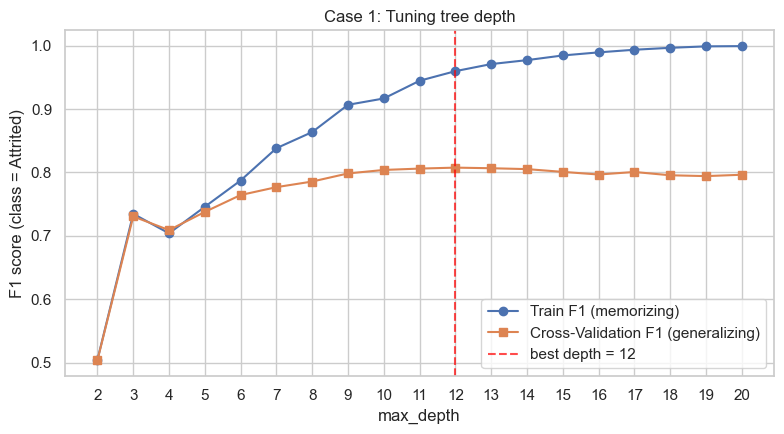

ความลึกที่ดีที่สุดจาก Cross-Validation: max_depth = 12


,max_depth,CV F1 (train set),Train F1
0,2,0.5036,0.5042
1,3,0.7305,0.7346
2,4,0.7089,0.7039
3,5,0.7377,0.7458
4,6,0.7643,0.7872
5,7,0.7767,0.8381
6,8,0.7856,0.8636
7,9,0.7984,0.9066
8,10,0.8038,0.9166
9,11,0.8060,0.9446


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
depths = range(2, 21)
rows = []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=RANDOM_STATE)
    cv_f1 = cross_val_score(m, X1_train, y1_train, cv=cv, scoring="f1").mean()
    m.fit(X1_train, y1_train)
    rows.append({"max_depth": d,
                 "CV F1 (train set)": cv_f1,
                 "Train F1": f1_score(y1_train, m.predict(X1_train))})

tune1 = pd.DataFrame(rows)
best_depth1 = int(tune1.loc[tune1["CV F1 (train set)"].idxmax(), "max_depth"])

plt.figure(figsize=(8, 4.5))
plt.plot(tune1["max_depth"], tune1["Train F1"], marker="o", label="Train F1 (memorizing)")
plt.plot(tune1["max_depth"], tune1["CV F1 (train set)"], marker="s", label="Cross-Validation F1 (generalizing)")
plt.axvline(best_depth1, color="red", ls="--", alpha=0.7, label=f"best depth = {best_depth1}")
plt.xlabel("max_depth"); plt.ylabel("F1 score (class = Attrited)")
plt.title("Case 1: Tuning tree depth")
plt.xticks(list(depths)); plt.legend(); plt.tight_layout(); plt.show()

print(f"ความลึกที่ดีที่สุดจาก Cross-Validation: max_depth = {best_depth1}")
tune1.round(4)

กราฟนี้คือภาพคลาสสิกของ **Bias–Variance Tradeoff**:
เส้น Train F1 ไต่ขึ้นเรื่อย ๆ จนแตะ 1.0 (ยิ่งลึกยิ่งจำข้อมูลได้ดี) แต่เส้น Cross-Validation ขึ้นถึงจุดหนึ่งแล้วนิ่ง/ตก
จุดสูงสุดของเส้น CV คือความลึกที่โมเดล **generalize** ได้ดีที่สุด

## 2.4 โมเดลสุดท้ายของ Case 1

              precision    recall  f1-score   support

    Existing     0.9680    0.9612    0.9646      1701
    Attrited     0.8042    0.8338    0.8187       325

    accuracy                         0.9408      2026
   macro avg     0.8861    0.8975    0.8917      2026
weighted avg     0.9417    0.9408    0.9412      2026



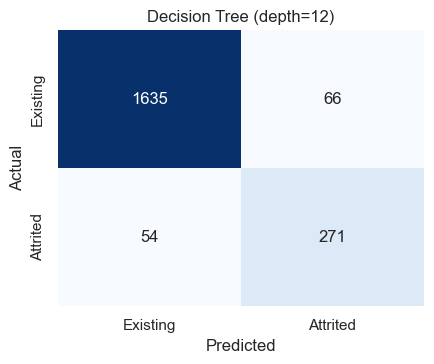

In [14]:
dt1 = DecisionTreeClassifier(max_depth=best_depth1, class_weight="balanced", random_state=RANDOM_STATE)
dt1.fit(X1_train, y1_train)

y1_pred_dt = dt1.predict(X1_test)
y1_prob_dt = dt1.predict_proba(X1_test)[:, 1]

print(classification_report(y1_test, y1_pred_dt, target_names=["Existing", "Attrited"], digits=4))
plot_cm(y1_test, y1_pred_dt, ["Existing", "Attrited"], f"Decision Tree (depth={best_depth1})")

### ทำไมถึงใส่ `class_weight="balanced"`

พารามิเตอร์นี้สั่งให้ต้นไม้ถ่วงน้ำหนักคลาสส่วนน้อยให้มากขึ้นตามสัดส่วนผกผัน
พูดง่าย ๆ คือ "ทายพลาดลูกค้าที่จะหนี ถือว่าผิดหนักกว่าทายพลาดลูกค้าที่อยู่ต่อ"
ผลคือโมเดลยอมแลก Precision ลงนิดหน่อย เพื่อดัน **Recall ของ Attrited** ขึ้น ซึ่งตรงกับโจทย์ธุรกิจ

## 2.5 มองเข้าไปในต้นไม้ — จุดแข็งที่ KNN ทำไม่ได้

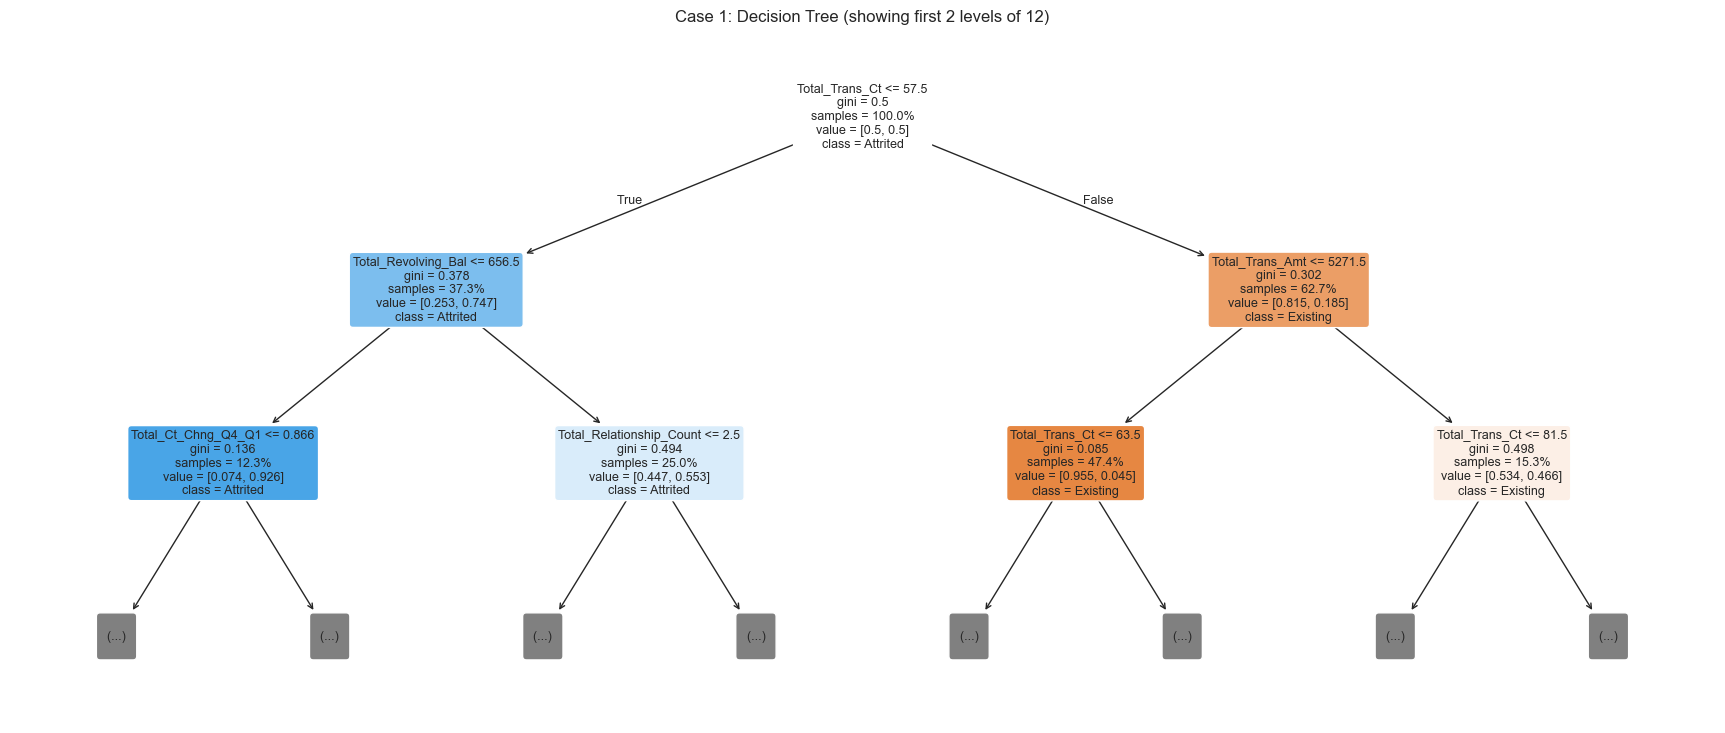

In [15]:
plt.figure(figsize=(22, 9))
plot_tree(dt1, max_depth=2, feature_names=X1.columns, class_names=["Existing", "Attrited"],
          filled=True, rounded=True, fontsize=9, proportion=True)
plt.title(f"Case 1: Decision Tree (showing first 2 levels of {best_depth1})")
plt.show()

In [16]:
# กฎการตัดสินใจในรูปแบบข้อความ (อ่านง่ายกว่า เอาไปคุยกับฝ่ายธุรกิจได้เลย)
print(export_text(dt1, feature_names=list(X1.columns), max_depth=2, decimals=1))

|--- Total_Trans_Ct <= 57.5
|   |--- Total_Revolving_Bal <= 656.5
|   |   |--- Total_Ct_Chng_Q4_Q1 <= 0.9
|   |   |   |--- truncated branch of depth 10
|   |   |--- Total_Ct_Chng_Q4_Q1 >  0.9
|   |   |   |--- truncated branch of depth 10
|   |--- Total_Revolving_Bal >  656.5
|   |   |--- Total_Relationship_Count <= 2.5
|   |   |   |--- truncated branch of depth 10
|   |   |--- Total_Relationship_Count >  2.5
|   |   |   |--- truncated branch of depth 10
|--- Total_Trans_Ct >  57.5
|   |--- Total_Trans_Amt <= 5271.5
|   |   |--- Total_Trans_Ct <= 63.5
|   |   |   |--- truncated branch of depth 8
|   |   |--- Total_Trans_Ct >  63.5
|   |   |   |--- truncated branch of depth 9
|   |--- Total_Trans_Amt >  5271.5
|   |   |--- Total_Trans_Ct <= 81.5
|   |   |   |--- truncated branch of depth 10
|   |   |--- Total_Trans_Ct >  81.5
|   |   |   |--- truncated branch of depth 8



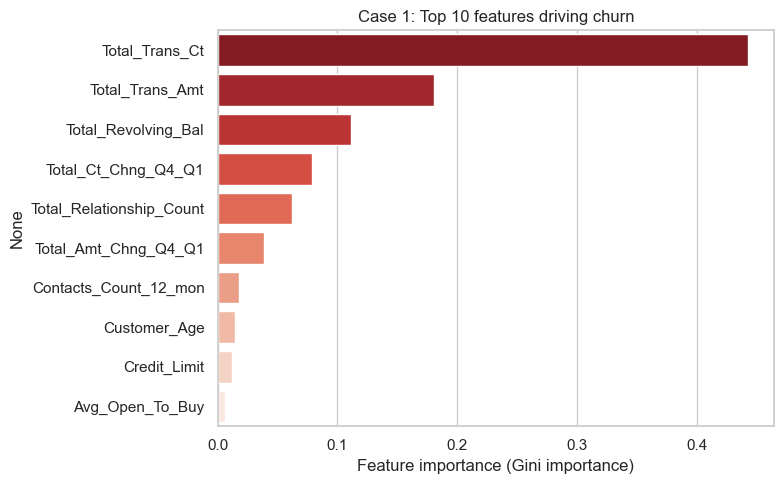

Total_Trans_Ct              0.4426
Total_Trans_Amt             0.1805
Total_Revolving_Bal         0.1114
Total_Ct_Chng_Q4_Q1         0.0784
Total_Relationship_Count    0.0622
Total_Amt_Chng_Q4_Q1        0.0386
Contacts_Count_12_mon       0.0180
Customer_Age                0.0141
Credit_Limit                0.0116
Avg_Open_To_Buy             0.0060
dtype: float64

In [17]:
imp1 = pd.Series(dt1.feature_importances_, index=X1.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=imp1.values[:10], y=imp1.index[:10], palette="Reds_r", hue=imp1.index[:10], legend=False)
plt.xlabel("Feature importance (Gini importance)")
plt.title("Case 1: Top 10 features driving churn")
plt.tight_layout(); plt.show()

imp1.head(10).round(4)

### 📌 สิ่งที่โมเดลบอกฝ่ายธุรกิจ (Case 1)

ฟีเจอร์ที่มีอิทธิพลสูงสุดล้วนเป็น **สัญญาณการใช้งานที่ลดลง** ไม่ใช่ข้อมูลประชากรศาสตร์:

1. `Total_Trans_Ct` (0.44) — จำนวนครั้งที่รูดบัตรน้อย = เริ่มหันไปใช้บัตรอื่น **นี่คือ root node ของต้นไม้ ที่เกณฑ์ 57.5 ครั้ง/ปี**
2. `Total_Trans_Amt` (0.18) — ยอดใช้จ่ายรวมต่ำ
3. `Total_Revolving_Bal` (0.11) — ยอดคงค้างใกล้ 0 คือสัญญาณอันตราย เพราะแปลว่าปิดยอดแล้วเลิกใช้
4. `Total_Ct_Chng_Q4_Q1` (0.08) — จำนวนครั้งที่รูดใน Q4 ลดลงเทียบกับ Q1 = กำลังถอยห่าง
5. `Total_Relationship_Count` (0.06) — ถือผลิตภัณฑ์กับธนาคารน้อย = ผูกพันน้อย ย้ายง่าย

ส่วนข้อมูลประชากรศาสตร์ (อายุ การศึกษา รายได้ สถานภาพสมรส) แทบไม่มีน้ำหนักเลย
สรุปสั้น ๆ คือ **"ลูกค้าจะหนีหรือไม่ ดูจากพฤติกรรมการใช้บัตร ไม่ใช่ดูว่าเขาเป็นใคร"**

**ข้อได้เปรียบที่ชัดที่สุดของ Decision Tree:** ผลลัพธ์ออกมาเป็น **กฎ if-else ที่อ่านออก**
ฝ่ายการตลาดเอาไปตั้งเป็นเงื่อนไขในระบบ CRM ได้ทันทีโดยไม่ต้องรันโมเดล
ขณะที่ KNN ตอบได้แค่ว่า "ลูกค้ารายนี้เหมือนเพื่อนบ้าน 5 คน" ซึ่งอธิบายต่อไม่ได้เลย

## 2.6 เปรียบเทียบกับโมเดลสัปดาห์ที่ 3 (KNN & Logistic Regression)

**สิ่งที่ต้องระวัง:** KNN วัดระยะทางแบบยุคลิด และ Logistic Regression ใช้ gradient descent
ทั้งคู่จึง **อ่อนไหวต่อสเกลของข้อมูลอย่างมาก** — `Total_Trans_Amt` (หลักหมื่น) จะกลบ `Months_Inactive_12_mon` (หลักหน่วย) จนหมด
จึงต้องทำ `StandardScaler` ก่อน โดย **`fit` บน train เท่านั้น** แล้ว `transform` ทั้งสองชุด (ป้องกันข้อมูล test รั่วเข้า train)

ส่วน **Decision Tree ไม่ต้อง scale เลย** เพราะมันแตกกิ่งด้วยการเทียบค่า threshold ทีละฟีเจอร์ ไม่ได้คำนวณระยะทางข้ามฟีเจอร์

In [18]:
scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X1_train)   # fit เฉพาะ train
X1_test_sc = scaler1.transform(X1_test)         # test แค่ transform

# --- หา k ที่ดีที่สุดของ KNN ด้วย CV (ให้ความยุติธรรมเท่ากับที่ tune tree) ---
k_rows = []
for k in [3, 5, 7, 9, 11, 15, 21]:
    s = cross_val_score(KNeighborsClassifier(n_neighbors=k), X1_train_sc, y1_train, cv=cv, scoring="f1").mean()
    k_rows.append({"k": k, "CV F1": s})
k_tune1 = pd.DataFrame(k_rows)
best_k1 = int(k_tune1.loc[k_tune1["CV F1"].idxmax(), "k"])
print(f"ค่า k ที่ดีที่สุดของ KNN: {best_k1}")
k_tune1.round(4)

ค่า k ที่ดีที่สุดของ KNN: 5


,k,CV F1
0,3,0.6200
1,5,0.6321
2,7,0.6044
3,9,0.5861
4,11,0.5774
5,15,0.5679
6,21,0.5351


In [19]:
knn1 = KNeighborsClassifier(n_neighbors=best_k1).fit(X1_train_sc, y1_train)
log1 = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE).fit(X1_train_sc, y1_train)

results1 = pd.DataFrame([
    score_row(f"Decision Tree (depth={best_depth1})", y1_test, y1_pred_dt, y1_prob_dt),
    score_row(f"KNN (k={best_k1})", y1_test, knn1.predict(X1_test_sc), knn1.predict_proba(X1_test_sc)[:, 1]),
    score_row("Logistic Regression", y1_test, log1.predict(X1_test_sc), log1.predict_proba(X1_test_sc)[:, 1]),
]).set_index("Model")

display(results1.style.background_gradient(cmap="Greens").format("{:.4f}"))

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Decision Tree (depth=12),0.9408,0.8042,0.8338,0.8187,0.9023
KNN (k=5),0.8963,0.8075,0.4646,0.5898,0.9060
Logistic Regression,0.8524,0.5256,0.8215,0.6411,0.9199


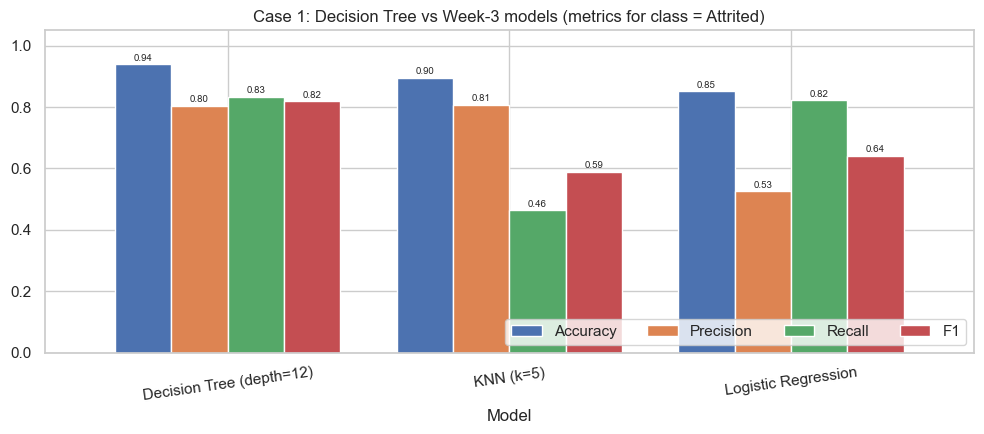

In [20]:
ax = results1[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", figsize=(10, 4.5), rot=8, ylim=(0, 1.05), width=0.8)
ax.set_title("Case 1: Decision Tree vs Week-3 models (metrics for class = Attrited)")
ax.legend(loc="lower right", ncol=4)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=1)
plt.tight_layout(); plt.show()

### 📊 สรุปผล Case 1

**Decision Tree ชนะในเมตริกที่สำคัญที่สุดของโจทย์** — F1 ของคลาส Attrited สูงกว่าคู่แข่งอย่างชัดเจน
โดยทำ Recall ได้สูงพอ ๆ กับ Logistic Regression แต่ Precision สูงกว่าเกือบเท่าตัว
แปลว่า **จับลูกค้าเสี่ยงได้พอ ๆ กัน แต่รบกวนลูกค้าที่ไม่ได้จะหนีน้อยกว่ามาก** = ต้นทุนแคมเปญถูกกว่า

เหตุผลอธิบายได้ด้วยธรรมชาติของอัลกอริทึม:

1. **ความสัมพันธ์ในข้อมูลนี้เป็นแบบ non-linear และมี interaction**
   ความเสี่ยง churn ไม่ได้เพิ่มขึ้นเป็นเส้นตรงตามยอดรูดบัตร แต่มีลักษณะ "ต่ำกว่าเกณฑ์นี้เมื่อไหร่ = อันตราย"
   ซึ่งเป็นรูปแบบ threshold ที่ต้นไม้จับได้ตรง ๆ แต่ Logistic Regression ที่ลากได้แค่เส้นแบ่งตรง ๆ ทำไม่ได้
   จึงต้องยอมทายว่า "เสี่ยง" กว้าง ๆ ไว้ก่อน ทำให้ Precision ต่ำ (0.53) ทั้งที่ Recall สูง
2. **KNN เจอปัญหา Curse of Dimensionality** — ฟีเจอร์ 20 กว่ามิติทำให้ระยะห่างระหว่างจุดใกล้เคียงกันไปหมด
   ยิ่งคลาส Attrited มีแค่ 16% เพื่อนบ้าน k ตัวจึงมักเป็นคลาส Existing เกือบทั้งหมด → **Recall ต่ำมาก (0.46)**
   คือ *พลาดลูกค้าที่กำลังจะหนีไปกว่าครึ่ง* ซึ่งใช้งานจริงไม่ได้เลย และ KNN ไม่มี `class_weight` ให้ปรับด้วย
3. **Decision Tree ไม่ต้อง scale และรับมือกับฟีเจอร์คนละหน่วยได้ทันที** — งาน preprocessing น้อยกว่ามาก

**ข้อสังเกตที่น่าสนใจ (ต้องพูดถึงอย่างตรงไปตรงมา):**
ถ้าดูที่ **ROC-AUC** อย่างเดียว Logistic Regression กลับได้สูงที่สุด (≈0.92) เหนือกว่า Decision Tree (≈0.90) เล็กน้อย
ไม่ใช่เพราะมันแยกแยะเก่งกว่า แต่เพราะ ROC-AUC วัด "คุณภาพการเรียงลำดับด้วยค่าความน่าจะเป็น"
ซึ่ง Logistic Regression ให้ค่าเป็นตัวเลขต่อเนื่องละเอียด ส่วน Decision Tree ให้ค่าความน่าจะเป็นแบบ**เป็นขั้น ๆ**
(ทุกคนที่ตกในใบเดียวกันได้คะแนนเท่ากันหมด) กราฟ ROC จึงหยาบกว่าโดยธรรมชาติ
แต่เมื่อ**ตัดสินใจจริงที่ threshold 0.5** ซึ่งเป็นสิ่งที่ระบบ Retention ใช้งานจริง Decision Tree ทำได้ดีกว่าชัดเจน

---

# 🟡 Case 2: Data-Driven Up-selling Strategy

> ธนาคารต้องการเพิ่มสัดส่วนผู้ถือบัตรระดับพรีเมียม (Silver, Gold, Platinum) จากฐานลูกค้าเดิมที่ถือบัตรระดับเริ่มต้น (Blue)
> โดยต้องการโมเดลที่สามารถคัดเลือกกลุ่มลูกค้าบัตร Blue ที่มีโปรไฟล์และพฤติกรรมการใช้จ่ายใกล้เคียง (Lookalike)
> กับกลุ่มลูกค้าที่ถือบัตรระดับสูงในปัจจุบัน เพื่อส่งแคมเปญอัปเกรดบัตรได้อย่างแม่นยำ

## 3.1 แปลงโจทย์ธุรกิจเป็นโจทย์ Machine Learning

โจทย์นี้ไม่ใช่แค่ "ทายว่าใครถือบัตรอะไร" แต่คือ **Lookalike Modeling**:

1. สอนโมเดลให้รู้จัก "หน้าตาของลูกค้าพรีเมียม" → Binary Classification: **Blue (0) vs Premium (1)**
2. เอาโมเดลไปให้คะแนนความน่าจะเป็น (`predict_proba`) กับลูกค้า **Blue** ทุกคน
3. ลูกค้า Blue ที่ได้คะแนนสูง = *"ระบบคิดว่าคนนี้คือพรีเมียม แต่ความจริงยังถือ Blue อยู่"*
   → **นี่แหละคือกลุ่มเป้าหมายของแคมเปญอัปเกรด**

จุดสำคัญคือ **"ทายผิด" ในเคสนี้ไม่ใช่ความผิดพลาด แต่คือคำตอบที่เราต้องการ**

**ฟีเจอร์ที่ต้องตัดออก (ตามที่พิสูจน์ไว้ในหัวข้อ 1.3):**
`Credit_Limit`, `Avg_Open_To_Buy`, `Avg_Utilization_Ratio` — ทั้งสามตัวเป็นตัวแทนของวงเงิน
ซึ่งถูกกำหนดพร้อมกับระดับบัตร ถ้าปล่อยไว้โมเดลจะแค่ท่อง "วงเงินสูง = พรีเมียม" แทนที่จะเรียนพฤติกรรมจริง

In [21]:
LEAK_COLS = ["Credit_Limit", "Avg_Open_To_Buy", "Avg_Utilization_Ratio"]

X2 = df_enc.drop(columns=["Card_Category"] + LEAK_COLS)
y2 = (df["Card_Category"] != "Blue").astype(int)      # 1 = Premium, 0 = Blue

print("ฟีเจอร์ที่ใช้ใน Case 2:", list(X2.columns))
print("\nจำนวนตัวอย่างแต่ละคลาส:")
print(y2.value_counts().rename({0: "Blue", 1: "Premium"}))
print(f"สัดส่วน Premium = {y2.mean():.2%}")

ฟีเจอร์ที่ใช้ใน Case 2: ['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Income_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Marital_Divorced', 'Marital_Married', 'Marital_Single', 'Marital_Unknown']

จำนวนตัวอย่างแต่ละคลาส:
Card_Category
Blue       9436
Premium     691
Name: count, dtype: int64
สัดส่วน Premium = 6.82%


In [22]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)
print("Train:", X2_train.shape, " Test:", X2_test.shape)
print("Premium ในชุด train:", y2_train.sum(), "คน | ในชุด test:", y2_test.sum(), "คน")

Train: (8101, 19)  Test: (2026, 19)
Premium ในชุด train: 553 คน | ในชุด test: 138 คน


## 3.2 พิสูจน์ว่า Data Leakage มีจริง

ก่อนไปต่อ ลองสร้างโมเดล 2 ตัวเทียบกัน: ตัวหนึ่งใส่ `Credit_Limit` เข้าไป อีกตัวไม่ใส่

In [23]:
X2_leak = df_enc.drop(columns=["Card_Category"])       # เวอร์ชันที่ "ลืม" ตัดฟีเจอร์รั่ว
X2L_train, X2L_test, _, _ = train_test_split(
    X2_leak, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)

dt_leak = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE)
dt_leak.fit(X2L_train, y2_train)

imp_leak = pd.Series(dt_leak.feature_importances_, index=X2_leak.columns).sort_values(ascending=False)
print("โมเดลที่ 'ลืม' ตัดฟีเจอร์รั่ว:")
print(f"  Recall (Premium) = {recall_score(y2_test, dt_leak.predict(X2L_test)):.4f}")
print("  ฟีเจอร์ที่โมเดลใช้มากที่สุด 3 อันดับแรก:")
print(imp_leak.head(3).round(4).to_string())

โมเดลที่ 'ลืม' ตัดฟีเจอร์รั่ว:
  Recall (Premium) = 0.9855
  ฟีเจอร์ที่โมเดลใช้มากที่สุด 3 อันดับแรก:
Credit_Limit       0.7542
Income_Category    0.1956
Avg_Open_To_Buy    0.0328


เห็นชัดว่าโมเดลทุ่มน้ำหนักไปที่ `Credit_Limit`/`Avg_Open_To_Buy` เกือบทั้งหมด
คะแนนดูสวย แต่ **ไร้ประโยชน์ทางธุรกิจ** เพราะมันแค่ย้อนอ่านผลลัพธ์ของการอนุมัติบัตร
ไม่ได้บอกเลยว่าลูกค้า Blue คนไหน *ใช้จ่ายเหมือน* คนพรีเมียม — เราจึงใช้เวอร์ชันที่ตัดออกแล้วต่อไป

## 3.3 หา `max_depth` และสร้างโมเดล Decision Tree

**Case 2 เลือกความลึกด้วย ROC-AUC ไม่ใช่ F1** (ต่างจาก Case 1) เพราะโจทย์ต่างกันโดยสิ้นเชิง:

* Case 1 ต้องการ **คำตอบขาด** ว่า "ลูกค้าคนนี้เสี่ยง churn ไหม" → ตัดสินที่ threshold 0.5 → ใช้ F1
* Case 2 ต้องการ **ลำดับ** ว่า "ควรส่งแคมเปญหาใครก่อน" → เราจะเอา `predict_proba` ไปเรียงอันดับ
  ไม่ได้สนใจว่าที่ threshold 0.5 มันตัดสินว่าอะไร → ใช้ **ROC-AUC** ซึ่งวัด "ความสามารถในการเรียงลำดับ" โดยตรง

อีกเหตุผลหนึ่งคือ ต้นไม้ที่ตื้นเกินไปให้ค่าความน่าจะเป็นได้แค่ไม่กี่ระดับ (ใบละ 1 ค่า)
ถ้าใบมีน้อยเกินไป ลูกค้าหลายพันคนจะได้คะแนนเท่ากันหมดจนเรียงอันดับไม่ได้

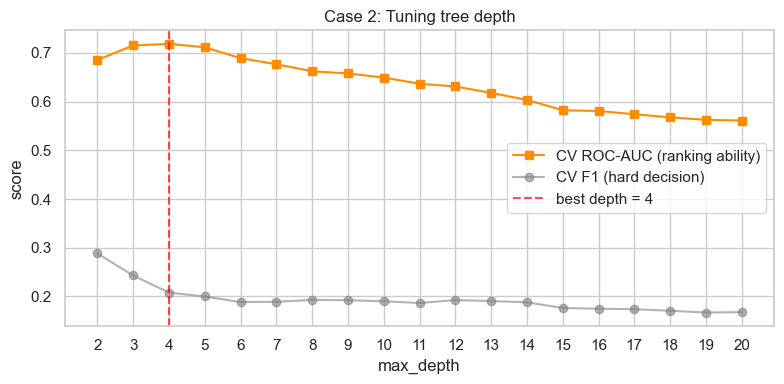

ความลึกที่ดีที่สุด (วัดด้วย ROC-AUC): max_depth = 4


,max_depth,CV ROC-AUC,CV F1
0,2,0.6856,0.2882
1,3,0.7154,0.2430
2,4,0.7187,0.2078
3,5,0.7116,0.1998
4,6,0.6893,0.1883
5,7,0.6768,0.1890
6,8,0.6623,0.1928
7,9,0.6579,0.1922
8,10,0.6495,0.1899
9,11,0.6368,0.1864


In [24]:
rows = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=RANDOM_STATE)
    rows.append({
        "max_depth": d,
        "CV ROC-AUC": cross_val_score(m, X2_train, y2_train, cv=cv, scoring="roc_auc").mean(),
        "CV F1": cross_val_score(m, X2_train, y2_train, cv=cv, scoring="f1").mean(),
    })

tune2 = pd.DataFrame(rows)
best_depth2 = int(tune2.loc[tune2["CV ROC-AUC"].idxmax(), "max_depth"])

plt.figure(figsize=(8, 4))
plt.plot(tune2["max_depth"], tune2["CV ROC-AUC"], marker="s", color="darkorange", label="CV ROC-AUC (ranking ability)")
plt.plot(tune2["max_depth"], tune2["CV F1"], marker="o", color="gray", alpha=0.6, label="CV F1 (hard decision)")
plt.axvline(best_depth2, color="red", ls="--", alpha=0.7, label=f"best depth = {best_depth2}")
plt.xlabel("max_depth"); plt.ylabel("score")
plt.title("Case 2: Tuning tree depth"); plt.xticks(list(depths)); plt.legend()
plt.tight_layout(); plt.show()

print(f"ความลึกที่ดีที่สุด (วัดด้วย ROC-AUC): max_depth = {best_depth2}")
tune2.round(4)

              precision    recall  f1-score   support

        Blue     0.9629    0.6462    0.7734      1888
     Premium     0.1199    0.6594    0.2029       138

    accuracy                         0.6471      2026
   macro avg     0.5414    0.6528    0.4881      2026
weighted avg     0.9055    0.6471    0.7345      2026



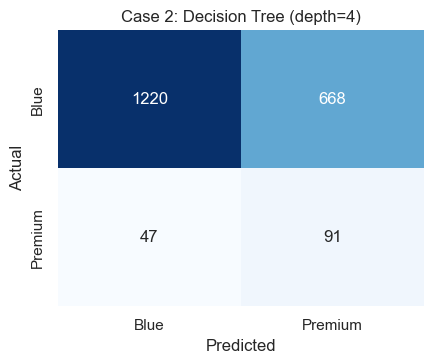

In [25]:
dt2 = DecisionTreeClassifier(max_depth=best_depth2, class_weight="balanced", random_state=RANDOM_STATE)
dt2.fit(X2_train, y2_train)

y2_pred_dt = dt2.predict(X2_test)
y2_prob_dt = dt2.predict_proba(X2_test)[:, 1]

print(classification_report(y2_test, y2_pred_dt, target_names=["Blue", "Premium"], digits=4))
plot_cm(y2_test, y2_pred_dt, ["Blue", "Premium"], f"Case 2: Decision Tree (depth={best_depth2})")

**อ่านคะแนนชุดนี้อย่างไร?**

Precision ของคลาส Premium จะดูต่ำ เพราะช่อง "ทายว่า Premium แต่จริง ๆ เป็น Blue" มีจำนวนมาก
ในงานทั่วไปนั่นคือความผิดพลาด แต่ในโจทย์นี้ **คนกลุ่มนั้นแหละคือผลลัพธ์ที่ธนาคารต้องการ**
คือลูกค้า Blue ที่โปรไฟล์เหมือนพรีเมียมจนโมเดลแยกไม่ออก

สิ่งที่เราต้องการจริง ๆ จึงคือ **ROC-AUC** (ความสามารถในการ *เรียงลำดับ* ลูกค้า) มากกว่า Precision
เพราะเราจะเอาคะแนนไปจัดอันดับ ไม่ได้เอาไปตัดสินขาดว่าใครเป็นพรีเมียม

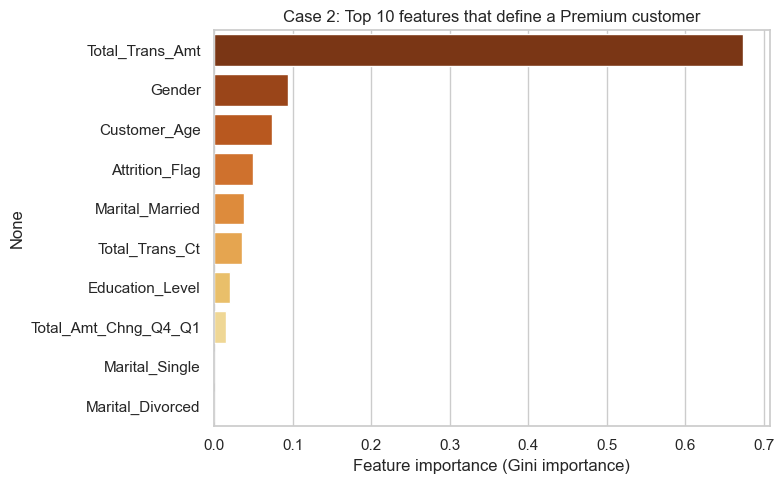

Total_Trans_Amt         0.6735
Gender                  0.0937
Customer_Age            0.0742
Attrition_Flag          0.0496
Marital_Married         0.0379
Total_Trans_Ct          0.0353
Education_Level         0.0199
Total_Amt_Chng_Q4_Q1    0.0158
Marital_Single          0.0000
Marital_Divorced        0.0000
dtype: float64

In [26]:
imp2 = pd.Series(dt2.feature_importances_, index=X2.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=imp2.values[:10], y=imp2.index[:10], palette="YlOrBr_r", hue=imp2.index[:10], legend=False)
plt.xlabel("Feature importance (Gini importance)")
plt.title("Case 2: Top 10 features that define a Premium customer")
plt.tight_layout(); plt.show()

imp2.head(10).round(4)

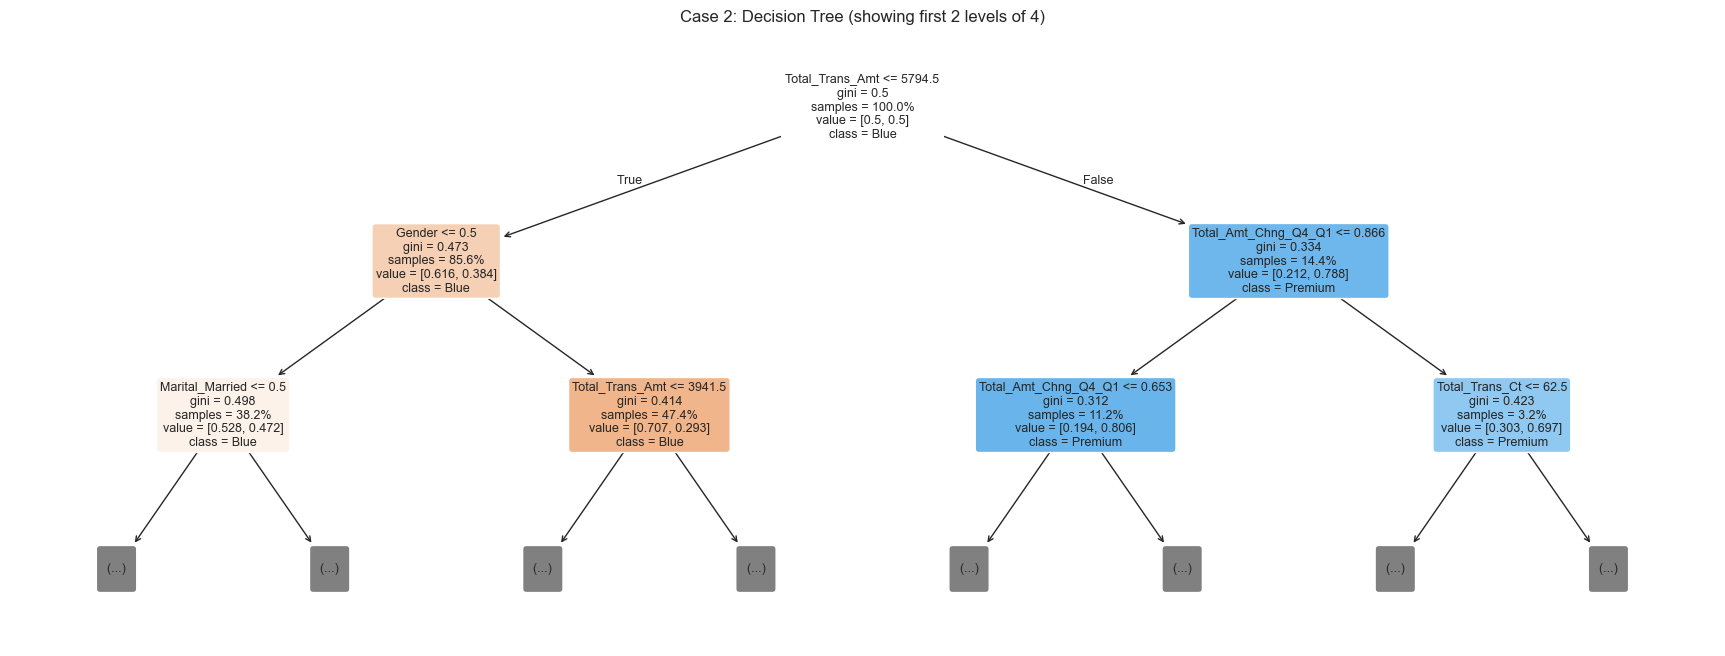

In [27]:
plt.figure(figsize=(22, 8))
plot_tree(dt2, max_depth=2, feature_names=X2.columns, class_names=["Blue", "Premium"],
          filled=True, rounded=True, fontsize=9, proportion=True)
plt.title(f"Case 2: Decision Tree (showing first 2 levels of {best_depth2})")
plt.show()

## 3.4 เปรียบเทียบกับโมเดลสัปดาห์ที่ 3

In [28]:
scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc = scaler2.transform(X2_test)

k_rows = []
for k in [3, 5, 7, 9, 11, 15, 21]:
    s = cross_val_score(KNeighborsClassifier(n_neighbors=k), X2_train_sc, y2_train, cv=cv, scoring="f1").mean()
    k_rows.append({"k": k, "CV F1": s})
k_tune2 = pd.DataFrame(k_rows)
best_k2 = int(k_tune2.loc[k_tune2["CV F1"].idxmax(), "k"])

knn2 = KNeighborsClassifier(n_neighbors=best_k2).fit(X2_train_sc, y2_train)
log2 = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE).fit(X2_train_sc, y2_train)

results2 = pd.DataFrame([
    score_row(f"Decision Tree (depth={best_depth2})", y2_test, y2_pred_dt, y2_prob_dt),
    score_row(f"KNN (k={best_k2})", y2_test, knn2.predict(X2_test_sc), knn2.predict_proba(X2_test_sc)[:, 1]),
    score_row("Logistic Regression", y2_test, log2.predict(X2_test_sc), log2.predict_proba(X2_test_sc)[:, 1]),
]).set_index("Model")

display(results2.style.background_gradient(cmap="Oranges").format("{:.4f}"))

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Decision Tree (depth=4),0.6471,0.1199,0.6594,0.2029,0.7229
KNN (k=3),0.9215,0.2308,0.0652,0.1017,0.6111
Logistic Regression,0.7192,0.1366,0.5870,0.2216,0.6971


**วิธีอ่านตารางนี้ให้ถูก — อย่าดู Accuracy!**

สังเกตว่า KNN ได้ Accuracy สูงถึง ~0.92 ซึ่งดูเหมือนชนะขาด แต่ดู Recall ประกอบจะพบว่าได้แค่ ~0.07
แปลว่า **KNN แทบจะทายว่า "Blue" ทุกคน** ซึ่งได้คะแนน Accuracy สวยงามโดยอัตโนมัติ (เพราะ 93% ของข้อมูลคือ Blue)
แต่หาลูกค้าเป้าหมายไม่เจอเลย — เป็นตัวอย่างคลาสสิกของ **Accuracy Paradox** ในข้อมูลไม่สมดุล

**เมตริกที่ใช้ตัดสินเคสนี้คือ ROC-AUC** เพราะเราต้องการ *ลำดับ* ไม่ใช่คำตอบขาด
และ **Decision Tree ทำได้ดีที่สุด (≈0.72)** เหนือ Logistic Regression (≈0.70) และ KNN (≈0.61) ชัดเจน

โดยรวม Case 2 ยากกว่า Case 1 มาก คะแนนทุกโมเดลต่ำลงทั้งกระดาน ซึ่งเป็นผลลัพธ์ที่ **สมเหตุสมผลทางธุรกิจ**:
เมื่อตัดวงเงินออกไปแล้ว ลูกค้า Blue กับลูกค้า Premium มีพฤติกรรมการใช้จ่ายทับซ้อนกันสูงมาก
พูดอีกอย่างคือ **มีลูกค้า Blue จำนวนไม่น้อยที่ "สมควรได้อัปเกรด" อยู่แล้ว** — ซึ่งก็คือสิ่งที่โจทย์ให้เราไปหานั่นเอง
โมเดลที่ได้คะแนนความ "แม่นยำ" สูงลิ่วในเคสนี้ต่างหากที่ควรถูกสงสัยว่ามีฟีเจอร์รั่วอยู่

## 3.5 🎯 ผลลัพธ์ที่ส่งให้ฝ่ายการตลาด — รายชื่อลูกค้าเป้าหมาย

นำโมเดล Decision Tree มาให้คะแนนลูกค้า **Blue ในชุด Test** (ข้อมูลที่โมเดลไม่เคยเห็น)
แล้วเรียงจากคะแนนสูงสุดลงมา = ลำดับความสำคัญในการส่งแคมเปญ

In [29]:
# เลือกเฉพาะลูกค้า Blue ในชุด test (index ยังตรงกับ df ต้นฉบับ เพราะ pandas เก็บ index เดิมไว้)
blue_test_idx = X2_test.index[y2_test == 0]

lookalike = pd.DataFrame({
    "CLIENTNUM": df.loc[blue_test_idx, "CLIENTNUM"],
    "Upgrade_Score": dt2.predict_proba(X2_test.loc[blue_test_idx])[:, 1],
    "Customer_Age": df.loc[blue_test_idx, "Customer_Age"],
    "Income_Category": df.loc[blue_test_idx, "Income_Category"],
    "Total_Trans_Amt": df.loc[blue_test_idx, "Total_Trans_Amt"],
    "Total_Trans_Ct": df.loc[blue_test_idx, "Total_Trans_Ct"],
    "Total_Relationship_Count": df.loc[blue_test_idx, "Total_Relationship_Count"],
    "Attrition_Flag": df.loc[blue_test_idx, "Attrition_Flag"],
}).sort_values("Upgrade_Score", ascending=False)

print(f"ลูกค้า Blue ในชุด test ทั้งหมด {len(lookalike)} คน")
print(f"จำนวนระดับคะแนนที่ต่างกัน: {lookalike['Upgrade_Score'].nunique()} ระดับ (= จำนวนใบของต้นไม้ที่ลูกค้ากลุ่มนี้ตกลงไป)")
print("\n🏆 Top 15 ลูกค้าที่ควรส่งแคมเปญอัปเกรดก่อน:")
display(lookalike.head(15).style.background_gradient(cmap="YlOrBr", subset=["Upgrade_Score"]).format({"Upgrade_Score": "{:.3f}"}))

ลูกค้า Blue ในชุด test ทั้งหมด 1888 คน
จำนวนระดับคะแนนที่ต่างกัน: 13 ระดับ (= จำนวนใบของต้นไม้ที่ลูกค้ากลุ่มนี้ตกลงไป)

🏆 Top 15 ลูกค้าที่ควรส่งแคมเปญอัปเกรดก่อน:


,CLIENTNUM,Upgrade_Score,Customer_Age,Income_Category,Total_Trans_Amt,Total_Trans_Ct,Total_Relationship_Count,Attrition_Flag
9676,710856558,0.843,45,Less than $40K,13989,105,2,Existing Customer
9571,717283008,0.843,44,Unknown,15225,108,2,Existing Customer
9596,715808808,0.843,48,Unknown,13614,104,2,Existing Customer
9467,715742658,0.843,41,Less than $40K,12489,97,1,Existing Customer
8588,717756258,0.843,49,$120K +,7761,84,3,Existing Customer
9312,819628158,0.843,42,$60K - $80K,14544,116,2,Existing Customer
9482,720748608,0.843,44,$40K - $60K,7672,66,1,Attrited Customer
8860,719258433,0.843,49,$60K - $80K,7561,91,2,Existing Customer
9155,720174033,0.843,46,$80K - $120K,12871,104,1,Existing Customer
8831,712053033,0.843,46,$80K - $120K,8444,81,1,Existing Customer


,Total_Trans_Amt,Total_Trans_Ct,Total_Relationship_Count,Customer_Age
Segment,,,,
Other Blue,3360.5,59.7,4.0,46.4
Target (Top 10%),11823.7,100.6,2.1,45.9


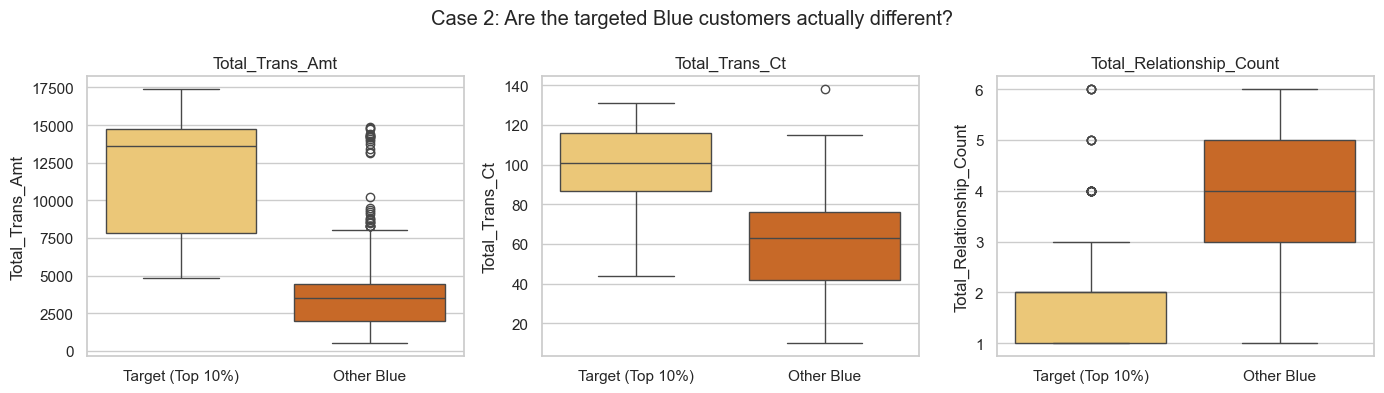

In [30]:
# เทียบพฤติกรรมกลุ่มเป้าหมาย (Top 10%) กับลูกค้า Blue ที่เหลือ
n_top = max(1, int(len(lookalike) * 0.10))
lookalike["Segment"] = "Other Blue"
lookalike.iloc[:n_top, lookalike.columns.get_loc("Segment")] = "Target (Top 10%)"

profile = lookalike.groupby("Segment")[
    ["Total_Trans_Amt", "Total_Trans_Ct", "Total_Relationship_Count", "Customer_Age"]
].mean().round(1)
display(profile)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Total_Trans_Amt", "Total_Trans_Ct", "Total_Relationship_Count"]):
    sns.boxplot(data=lookalike, x="Segment", y=col, ax=ax, palette="YlOrBr",
                hue="Segment", legend=False, order=["Target (Top 10%)", "Other Blue"])
    ax.set_title(col); ax.set_xlabel("")
plt.suptitle("Case 2: Are the targeted Blue customers actually different?")
plt.tight_layout(); plt.show()

### 📌 สิ่งที่โมเดลบอกฝ่ายธุรกิจ (Case 2)

กลุ่มเป้าหมาย Top 10% ที่โมเดลคัดมา มี **ยอดใช้จ่ายและความถี่ในการรูดบัตรสูงกว่าลูกค้า Blue ทั่วไปอย่างเห็นได้ชัด**
แปลว่าโมเดลไม่ได้สุ่มเลือก แต่คัดคนที่ "ใช้จ่ายระดับพรีเมียมอยู่แล้วแต่ยังถือบัตร Blue" ได้จริง

แต่กลุ่มเป้าหมายกลับ **ถือผลิตภัณฑ์กับธนาคารน้อยกว่า** (เฉลี่ย ~2 อย่าง เทียบกับ ~4 อย่างของ Blue ทั่วไป)
ซึ่งอ่านได้สองแบบ: อาจเป็นลูกค้าที่ใช้จ่ายเก่งแต่ยังผูกพันกับธนาคารน้อย (= โอกาสขายเพิ่ม)
หรืออาจเป็นเพราะกลุ่มพรีเมียมในข้อมูลเดิมก็ถือผลิตภัณฑ์น้อยอยู่แล้ว โมเดลจึงเรียนรู้รูปแบบนี้มา — ควรตรวจสอบกับฝ่ายธุรกิจก่อน

**⚠️ ข้อควรระวังด้านจริยธรรม:** ในกราฟ feature importance ของ Case 2 จะเห็นว่า `Gender` ติดอันดับต้น ๆ
การส่งแคมเปญโดยอิงเพศเป็นเกณฑ์อาจเข้าข่าย **การเลือกปฏิบัติ** และผิดหลักการให้บริการทางการเงินอย่างเป็นธรรม
ในการใช้งานจริงควรพิจารณาตัดฟีเจอร์นี้ออก แล้วดูว่าคะแนน ROC-AUC ลดลงมากหรือไม่

**ข้อควรระวังก่อนใช้งานจริง:** ควรกรองลูกค้าที่ `Attrition_Flag = Attrited` ออกก่อนส่งแคมเปญ
(ไม่มีประโยชน์ที่จะเชิญอัปเกรดบัตรให้คนที่เลิกใช้บริการไปแล้ว) — นี่คือจุดที่โมเดล Case 1 กับ Case 2 ทำงานเสริมกันได้

---

# 4. สรุปผลรวม — Decision Tree เทียบกับโมเดลสัปดาห์ที่ 3

In [31]:
summary = pd.concat([
    results1.assign(Case="Case 1: Churn").reset_index(),
    results2.assign(Case="Case 2: Up-selling").reset_index(),
])[["Case", "Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].set_index(["Case", "Model"])

display(summary.style.background_gradient(cmap="Greens", axis=0).format("{:.4f}"))

## 4.1 ตารางเปรียบเทียบเชิงคุณสมบัติ

| ประเด็น |  Decision Tree | KNN | Logistic Regression |
|---------|-----------------|-----|---------------------|
| **ต้องทำ Feature Scaling?** | ❌ ไม่ต้อง (เทียบ threshold ทีละฟีเจอร์) | ✅ จำเป็นมาก (ใช้ระยะทางยุคลิด) | ✅ จำเป็น (ช่วยให้ลู่เข้าเร็ว) |
| **จับความสัมพันธ์ non-linear** | ✅ ได้เอง | ✅ ได้ (แต่แพ้มิติสูง) | ❌ ได้แค่เส้นแบ่งตรง |
| **จับ interaction ระหว่างฟีเจอร์** | ✅ ได้เอง จากการซ้อนกิ่ง | ⚠️ ทางอ้อม | ❌ ต้องสร้างฟีเจอร์เอง |
| **อธิบายผลได้ (Interpretability)** | ✅ ออกมาเป็นกฎ if-else อ่านออก | ❌ อธิบายไม่ได้เลย | ⚠️ ดูค่าสัมประสิทธิ์ได้ แต่ตีความยากเมื่อมีหลายตัวแปร |
| **รับมือข้อมูลไม่สมดุล** | ✅ มี `class_weight` | ❌ ไม่มี | ✅ มี `class_weight` |
| **ความเร็วตอนทำนาย** | ✅ เร็วมาก (ไล่ลงกิ่ง) | ❌ ช้า ต้องเทียบทุกจุดในชุด train | ✅ เร็วมาก |
| **จุดอ่อนหลัก** | Overfit ง่ายถ้าไม่ทำ pruning | Curse of dimensionality | สมมติฐานความเป็นเส้นตรง |

## 4.2 ข้อสรุป

1. **Decision Tree ให้ผลดีที่สุดในเมตริกที่ตรงกับโจทย์ของทั้งสองเคส**
   * Case 1 → **F1 ของคลาส Attrited สูงสุด (≈0.82)** จับลูกค้าเสี่ยงได้พอ ๆ กับ Logistic Regression แต่แม่นกว่ามาก
   * Case 2 → **ROC-AUC สูงสุด (≈0.72)** เรียงลำดับลูกค้าเป้าหมายได้ดีที่สุด
   * ข้อยกเว้นที่ต้องยอมรับ: ROC-AUC ของ Case 1 Logistic Regression สูงกว่าเล็กน้อย
     เพราะต้นไม้ให้ค่าความน่าจะเป็นเป็นขั้น ๆ ตามจำนวนใบ ไม่ได้ต่อเนื่องเหมือนสมการถดถอย

2. **เหตุผลที่ชนะไม่ใช่เรื่องบังเอิญ** — ข้อมูลชุดนี้มีลักษณะที่เข้าทางต้นไม้พอดี:
   ฟีเจอร์อยู่คนละหน่วยกันสุดขั้ว (บาทหลักหมื่น vs จำนวนเดือนหลักหน่วย), ความสัมพันธ์เป็นแบบมีเกณฑ์ตัด (threshold),
   มีตัวแปรหมวดหมู่ผสมกับตัวเลข และมีมิติค่อนข้างสูงซึ่งเป็นจุดตายของ KNN

3. **KNN ทำผลงานแย่ที่สุดในคลาสส่วนน้อยทั้งสองเคส** เพราะเมื่อคลาสเป้าหมายมีเพียง 7–16%
   เพื่อนบ้าน k ตัวที่ใกล้ที่สุดมักเป็นคลาสใหญ่เกือบทั้งหมด และ KNN ไม่มีกลไกถ่วงน้ำหนักคลาสให้ปรับ
   Accuracy ที่ดูสูงของ KNN ใน Case 2 (≈0.92) จึงเป็นภาพลวงตาล้วน ๆ (Accuracy Paradox)

4. **ข้อได้เปรียบที่สำคัญที่สุดคือการอธิบายได้** — ทั้งสองเคสเป็นงานที่ต้องส่งต่อให้ฝ่ายธุรกิจนำไปปฏิบัติ
   Decision Tree ให้กฎที่เอาไปตั้งเงื่อนไขในระบบ CRM ได้ทันที และเมื่อโมเดลตัดสินใจผิด เราตามสืบได้ว่าผิดที่กิ่งไหน
   ซึ่งในงานสถาบันการเงินที่ต้องอธิบายเหตุผลให้ลูกค้าและผู้กำกับดูแลได้ ถือเป็นข้อได้เปรียบที่สำคัญกว่าคะแนนที่สูงกว่าเสียอีก

5. **สิ่งที่ต้องระวังเมื่อใช้ Decision Tree** — ถ้าไม่จำกัด `max_depth` ต้นไม้จะจำข้อมูลฝึกได้ 100% (F1 = 1.0 บน train)
   แต่ใช้กับข้อมูลจริงไม่ได้ การทำ pruning ด้วย cross-validation จึงเป็นขั้นตอนที่ข้ามไม่ได้